## Netflix Analytics Dashboard

* Step 1: Load Dataset
* Step 2: Understand Dataset
* Step 3: Data Cleaning
* Step 4: Exploratory Data Analysis (EDA)
* Step 5: Feature Engineering
* Step 6: Export Clean Dataset
* Step 7: Import into Power BI
* Step 8: Create DAX Measures
* Step 9: Build Dashboard
* Step 10: Publish Project

In [3]:
import pandas as pd # read and manipulate data
import numpy as  np # numerical computing 
import matplotlib.pyplot as plt # visualization 
import seaborn as sns # statistical data visualization 
plt.style.use("ggplot") 
import warnings # ignore warnings
warnings.filterwarnings("ignore")

In [7]:
df=pd.read_csv(r"D:\netflix_titles.csv") # load dataset

In [8]:
df.head() # display first 5 rows of the dataset

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.tail() # displaying last 5 rows of the dataset 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [12]:
df.shape # display the shape of the dataset  8807rows and 12 columns

(8807, 12)

In [14]:
df.columns # display the columns of the dataset 

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [15]:
df.info() # display the information of the dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [16]:
df.describe() # display the statistical summary of the dataset

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [17]:
df.describe(include="object") # display the categorical summary

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


## check Missing values

In [18]:
df.isnull().sum() # check for missing values in the dataset

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

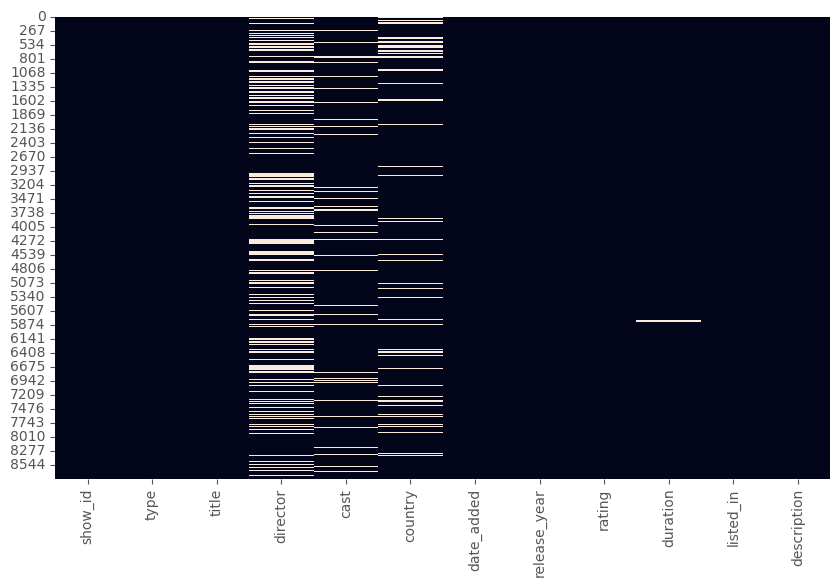

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

## Check Duplicate Rows

In [22]:
df.duplicated().sum() # check for duplicate values in the dataset

np.int64(0)

In [25]:
df.drop_duplicates(inplace=True) # remove duplicates if needed

## Clean Data

In [35]:
print(df["date_added"].dtype)

datetime64[ns]


In [36]:
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

In [37]:
print(df["date_added"].dtype)

print(df["date_added"].head())

print(df["date_added"].apply(type).value_counts())

datetime64[ns]
0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: date_added, dtype: datetime64[ns]
date_added
<class 'pandas._libs.tslibs.nattype.NaTType'>    8807
Name: count, dtype: int64


In [38]:
df["date_added"] = pd.to_datetime(df["date_added"])

In [39]:
df["year_added"]=df["date_added"].dt.year

In [40]:
df["month_added"]=df["date_added"].dt.month_name()

In [41]:
df["day_added"]=df["date_added"].dt.day

## Exploratory Data Analysis(EDA)

In [43]:
movies=df[df["type"]=="movie"] # total Movies

In [45]:
tv=df[df["type"]=="tv show"] # Total tv shows
tv.shape

(0, 15)

In [47]:
df["type"].value_counts() # movies vs Tv Shows

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

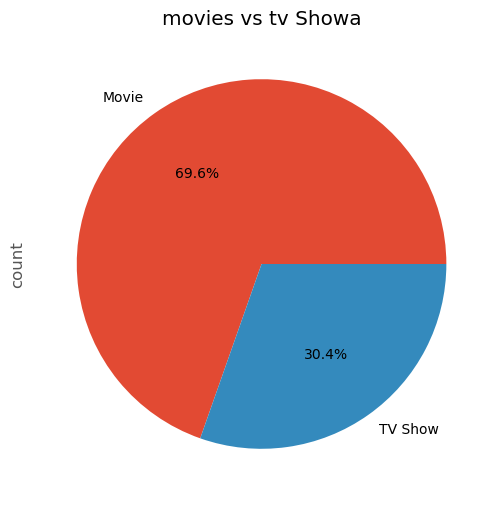

In [51]:
plt.figure(figsize=(6,6))
df["type"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("movies vs tv Showa")
plt.show()

In [54]:
top_country=df["country"].value_counts().head(10) # Top 10 Countries
top_country

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

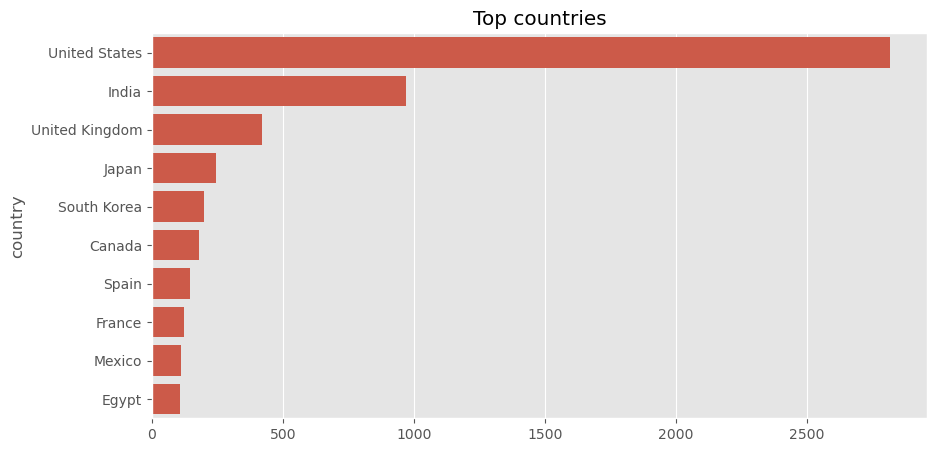

In [53]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_country.values,y=top_country.index)
plt.title("Top countries")
plt.show()

In [57]:
df["rating"].value_counts() # top rating 

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

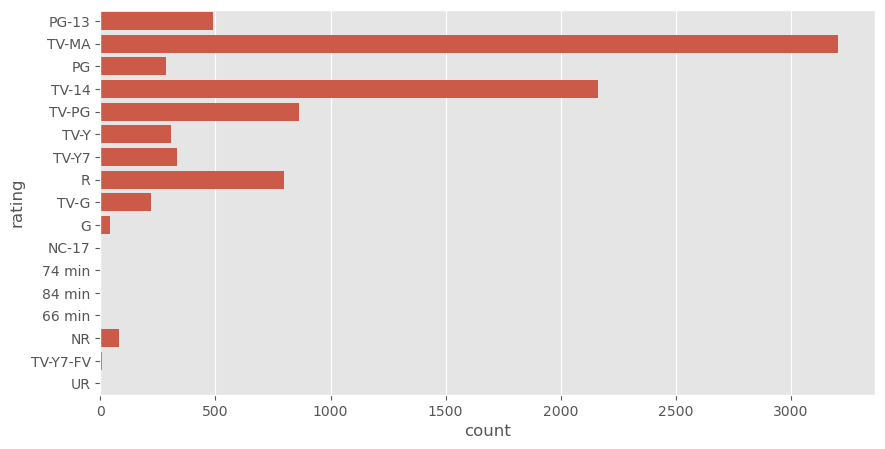

In [56]:
plt.figure(figsize=(10,5))
sns.countplot(y="rating",data=df)
plt.show()

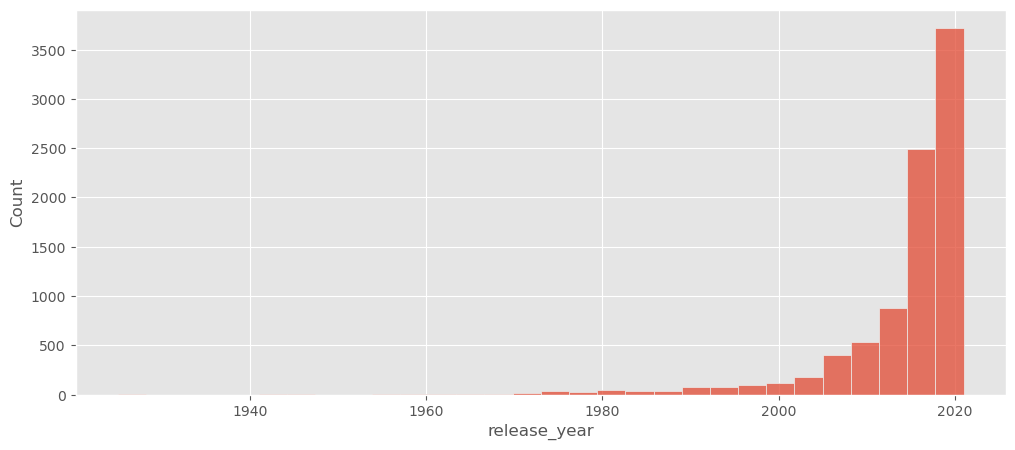

In [ ]:
plt.figure(figsize=(12,5))  # Release year Distribution
sns.histplot(df["release_year"],bins=30)
plt.show()


In [60]:
df["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [62]:
df["director"].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

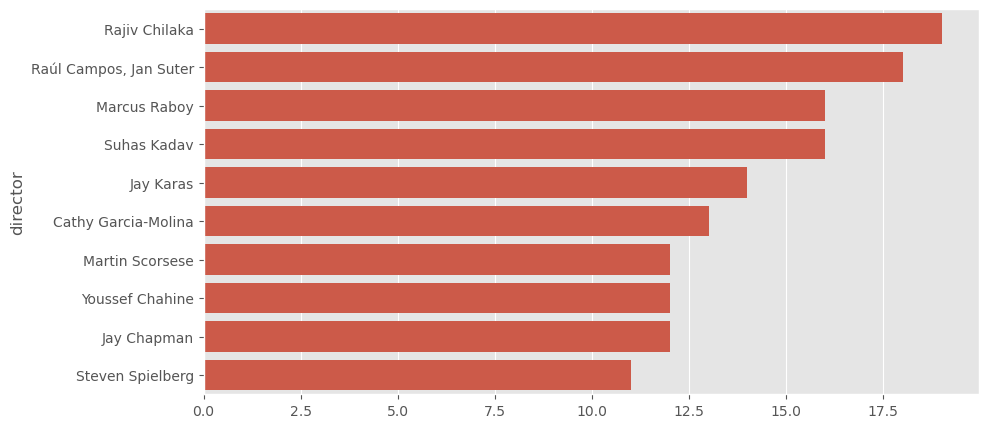

In [64]:
top_director=df["director"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_director.values,y=top_director.index)
plt.show()

## Feature Enginerring

In [67]:
movies=df[df["type"]=="movie"]
movies["duration"]=movies["duration"].str.replace("min","")
movies["duration"]=movies["duration"].astype(float)

In [68]:
df.to_csv("cleaned_netflix.csv",index=False)